In [1]:
import xarray as xr
import glob
import os
import cftime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
def anom(data):
    return (data - np.mean(data[:30]))

def lin_model(df, indep_var1, dep_var,  indep_vars=None):
    Y1=df[dep_var]
    X1=df[indep_var1]
    if indep_vars:
        X=np.stack([df[indep] for indep in indep_vars]).T
    else:
        X=X1
    model=sm.OLS(Y1,X)
    results=model.fit()
    return results

def construct_df_variants(df, percent):
    df_dict = {}
    end_years = [] # Dictionary to store end years of each chunk
    shape_80 = int(df.shape[0] * percent)  # Define the row number for given percentage
    
    # Ensure that we only take slices ending at the last year
    for i in range(df.shape[0] - shape_80 + 1):
        ratings_df = df.iloc[i:i + shape_80, :]
        df_dict[i] = ratings_df
        end_years.append(df.index[i + shape_80 - 1])  # Store the end year
    
    return df_dict, end_years

def sensitivity_analysis(somedict, indep_var, dep_var, indep_var_list):
    results=[]
    for element in somedict.values():
        a=lin_model(element, indep_var, dep_var, indep_var_list)
        param=a.params[0]
        results.append(param)
    return {indep_var:results}


def hist_plot(letstry):
    # Extract variable name and values
    name = list(letstry.keys())[0]
    mmlist = list(letstry.values())[0]  # Fix extraction of values

    # Compute mean
    mean = np.mean(mmlist)
    std=np.std(mmlist)
    # Create histogram
    counts, bins, _ = plt.hist(mmlist, bins=np.linspace(np.min(mmlist), np.max(mmlist), num=30, endpoint=True), 
                     density=True, weights=(np.ones_like(mmlist) / float(len(mmlist))).tolist(), 
                      alpha=0.7, color="blue", edgecolor="black")
    # Plot vertical mean line
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label="Mean "+str(round(mean,3)))
    #Plot range of one standard deviation around mean
    curve1 = mean + std
    curve2 = mean - std
    plt.fill_betweenx(y=[0, max(counts)], x1=curve1, x2=curve2, color='red', alpha=0.3, label="±1 Std Dev")
    # Labels and title
    plt.xlabel(name+' Regression Coefficient')
    plt.ylabel("Relative Frequency")
    plt.title(f"Distribution of Regression Coefficient from {name}")
    plt.legend()
    plt.savefig(name+'_Reg_Coeff_Distrib.jpg')
    # Show plot
    plt.show()


In [3]:

# Path to the directory containing the NetCDF files
base_dir = "/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/preproc/multiple_regression_indices/ua50_spv/"

# Use glob to find all NetCDF files
files = glob.glob(os.path.join(base_dir, "*.nc"))

# Dictionary to store datasets per model
model_datasets = {}

def standardize_time(ds):
    """Convert dataset time coordinates to a standard calendar."""
    if "time" in ds.coords:
        ds["time"] = xr.decode_cf(ds).time  # Decode time while handling different calendars
    return ds

# Process files
for file in files:
    # Extract model and ensemble member from filename
    filename = os.path.basename(file)
    parts = filename.split("_")
    model = parts[1]  # Extract model name (e.g., ACCESS-CM2)
    ensemble = parts[4]  # Extract ensemble member (e.g., r1i1p1f1)
    
    # Open the dataset and standardize time
    ds = xr.open_dataset(file)
    ds = standardize_time(ds)
    
    # Store in dictionary under the model
    if model not in model_datasets:
        model_datasets[model] = []
    model_datasets[model].append(ds)

# List to store mean datasets per model
model_means = []

# Process each model
for model, ds_list in model_datasets.items():
    # Concatenate over a new ensemble dimension
    combined = xr.concat(ds_list, dim="ensemble")
    
    # Take the mean over the ensemble dimension
    mean_ds = combined.mean(dim="ensemble")
    
    # Add a new coordinate for model
    mean_ds = mean_ds.expand_dims({"model": [model]})
    
    # Store the processed dataset
    model_means.append(mean_ds)

model_means_same_time = []
# Concatenate all models along the model dimension
for model in model_means:
    model['time'] = model_means[0].time
    model_means_same_time.append(model)

final_spv = xr.concat(model_means_same_time, dim="model")

# # Save to a new NetCDF file
# output_path = os.path.join(base_dir, "ensemble_mean_by_model.nc")
# final_ds.to_netcdf(output_path)

# print(f"Saved ensemble mean dataset to {output_path}")

In [4]:

# Path to the directory containing the NetCDF files
base_dir = "/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/preproc/multiple_regression_indices/gw/"

# Use glob to find all NetCDF files
files = glob.glob(os.path.join(base_dir, "*.nc"))

# Dictionary to store datasets per model
model_datasets = {}

def standardize_time(ds):
    """Convert dataset time coordinates to a standard calendar."""
    if "time" in ds.coords:
        ds["time"] = xr.decode_cf(ds).time  # Decode time while handling different calendars
    return ds

# Process files
for file in files:
    # Extract model and ensemble member from filename
    filename = os.path.basename(file)
    parts = filename.split("_")
    model = parts[1]  # Extract model name (e.g., ACCESS-CM2)
    ensemble = parts[4]  # Extract ensemble member (e.g., r1i1p1f1)
    
    # Open the dataset and standardize time
    ds = xr.open_dataset(file)
    ds = standardize_time(ds)
    
    # Store in dictionary under the model
    if model not in model_datasets:
        model_datasets[model] = []
    model_datasets[model].append(ds)

# List to store mean datasets per model
model_means = []

# Process each model
for model, ds_list in model_datasets.items():
    # Concatenate over a new ensemble dimension
    combined = xr.concat(ds_list, dim="ensemble")
    
    # Take the mean over the ensemble dimension
    mean_ds = combined.mean(dim="ensemble")
    
    # Add a new coordinate for model
    mean_ds = mean_ds.expand_dims({"model": [model]})
    
    # Store the processed dataset
    model_means.append(mean_ds)

model_means_same_time = []
# Concatenate all models along the model dimension
for model in model_means:
    model['time'] = model_means[0].time
    model_means_same_time.append(model)

final_gw = xr.concat(model_means_same_time, dim="model")

# # Save to a new NetCDF file
# output_path = os.path.join(base_dir, "ensemble_mean_by_model.nc")
# final_ds.to_netcdf(output_path)

# print(f"Saved ensemble mean dataset to {output_path}")

In [5]:
2023-1950

73

In [6]:
def regressor_EESC_GW(gw_ts):
    eesc_ts = pd.read_csv('/home/jmindlin/causal_EDJ/send_to_LIM/GW_EESC_polar_ozoneloss.csv')
    for i in range(len(eesc_ts[:8])):
        eesc_ts['EESC_polar'][i] = eesc_ts['EESC_polar'][8]
    df = pd.DataFrame({'EESC':eesc_ts['EESC_polar'][10:79] - eesc_ts['EESC_polar'][8],'GW':gw_ts})
    regressors_out = sm.add_constant(df.values)
    return regressors_out, df

SPV_reg_80 = {}
for model in final_gw.model[:]:
    df_spv = {}
    df_spv['GW'] = anom(final_gw.sel(model=model).tas.sel(time=slice('1950','2100')).values)
    df_spv['SPV'] = anom(final_spv.sel(model=model).ua.sel(time=slice('1950','2100')).values)
    eesc_ts = pd.read_csv('/home/jmindlin/causal_EDJ/send_to_LIM/GW_EESC_polar_ozoneloss.csv')
    for i in range(len(eesc_ts[:8])):
        eesc_ts.loc[i,'EESC_polar'] = eesc_ts.loc[8,'EESC_polar']

    EESC_anom = eesc_ts.loc[1:'EESC_polar'] - eesc_ts.loc[8,'EESC_polar']
    df_spv['EESC'] = np.array(EESC_anom['EESC_polar'].values)
    df_dict, end_years_80 =construct_df_variants(pd.DataFrame(df_spv), 0.3)
    results = sensitivity_analysis(df_dict, 'EESC', 'SPV',['EESC','GW'])
    SPV_reg_80[str(model.values)] = np.array(results['EESC'])

SPV_reg_full = {}
for model in final_gw.model[:]:
    df_spv = {}
    df_spv['GW'] = anom(final_gw.sel(model=model).tas.sel(time=slice('1950','2100')).values)
    df_spv['SPV'] = anom(final_spv.sel(model=model).ua.sel(time=slice('1950','2100')).values)
    eesc_ts = pd.read_csv('/home/jmindlin/causal_EDJ/send_to_LIM/GW_EESC_polar_ozoneloss.csv')
    for i in range(len(eesc_ts[:8])):
        eesc_ts.loc[i,'EESC_polar'] = eesc_ts.loc[8,'EESC_polar']

    EESC_anom = eesc_ts.loc[1:'EESC_polar'] - eesc_ts.loc[8,'EESC_polar']
    df_spv['EESC'] = np.array(EESC_anom['EESC_polar'].values)
    df_dict, end_years_80 =construct_df_variants(pd.DataFrame(df_spv), 1)
    results = sensitivity_analysis(df_dict, 'EESC', 'SPV',['EESC','GW'])
    SPV_reg_full[str(model.values)] = np.array(results['EESC'])

era_df = pd.read_csv('/climca/people/jmindlin/work_folders/EDJ_causal_network/Work/era5_ersst_drivers.csv',index_col='Unnamed: 0')
era_df['GW_DJF'] = anom(era_df['GW_DJF'])
era_df['SPV_OND'] = anom(era_df['SPV_OND'])
era_df['EESC'] = np.array(EESC_anom['EESC_polar'].values)[:74]
era_df_dict, end_years_era =construct_df_variants(era_df.iloc[30:], 1)
OBS_reg_SPV=sensitivity_analysis(era_df_dict, 'GW_DJF', 'SPV_OND',['GW_DJF','EESC'])
OBS_reg_EESC=sensitivity_analysis(era_df_dict, 'EESC', 'SPV_OND',['EESC','GW_DJF'])


/tmp/ipykernel_2471702/1037072335.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  param=a.params[0]
/tmp/ipykernel_2471702/1037072335.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  param=a.params[0]
/tmp/ipykernel_2471702/1037072335.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  param=a.params[0]
/tmp/ipykernel_2471702/1037072335.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a

In [7]:
len(df_spv['EESC'])*0.3

45.0

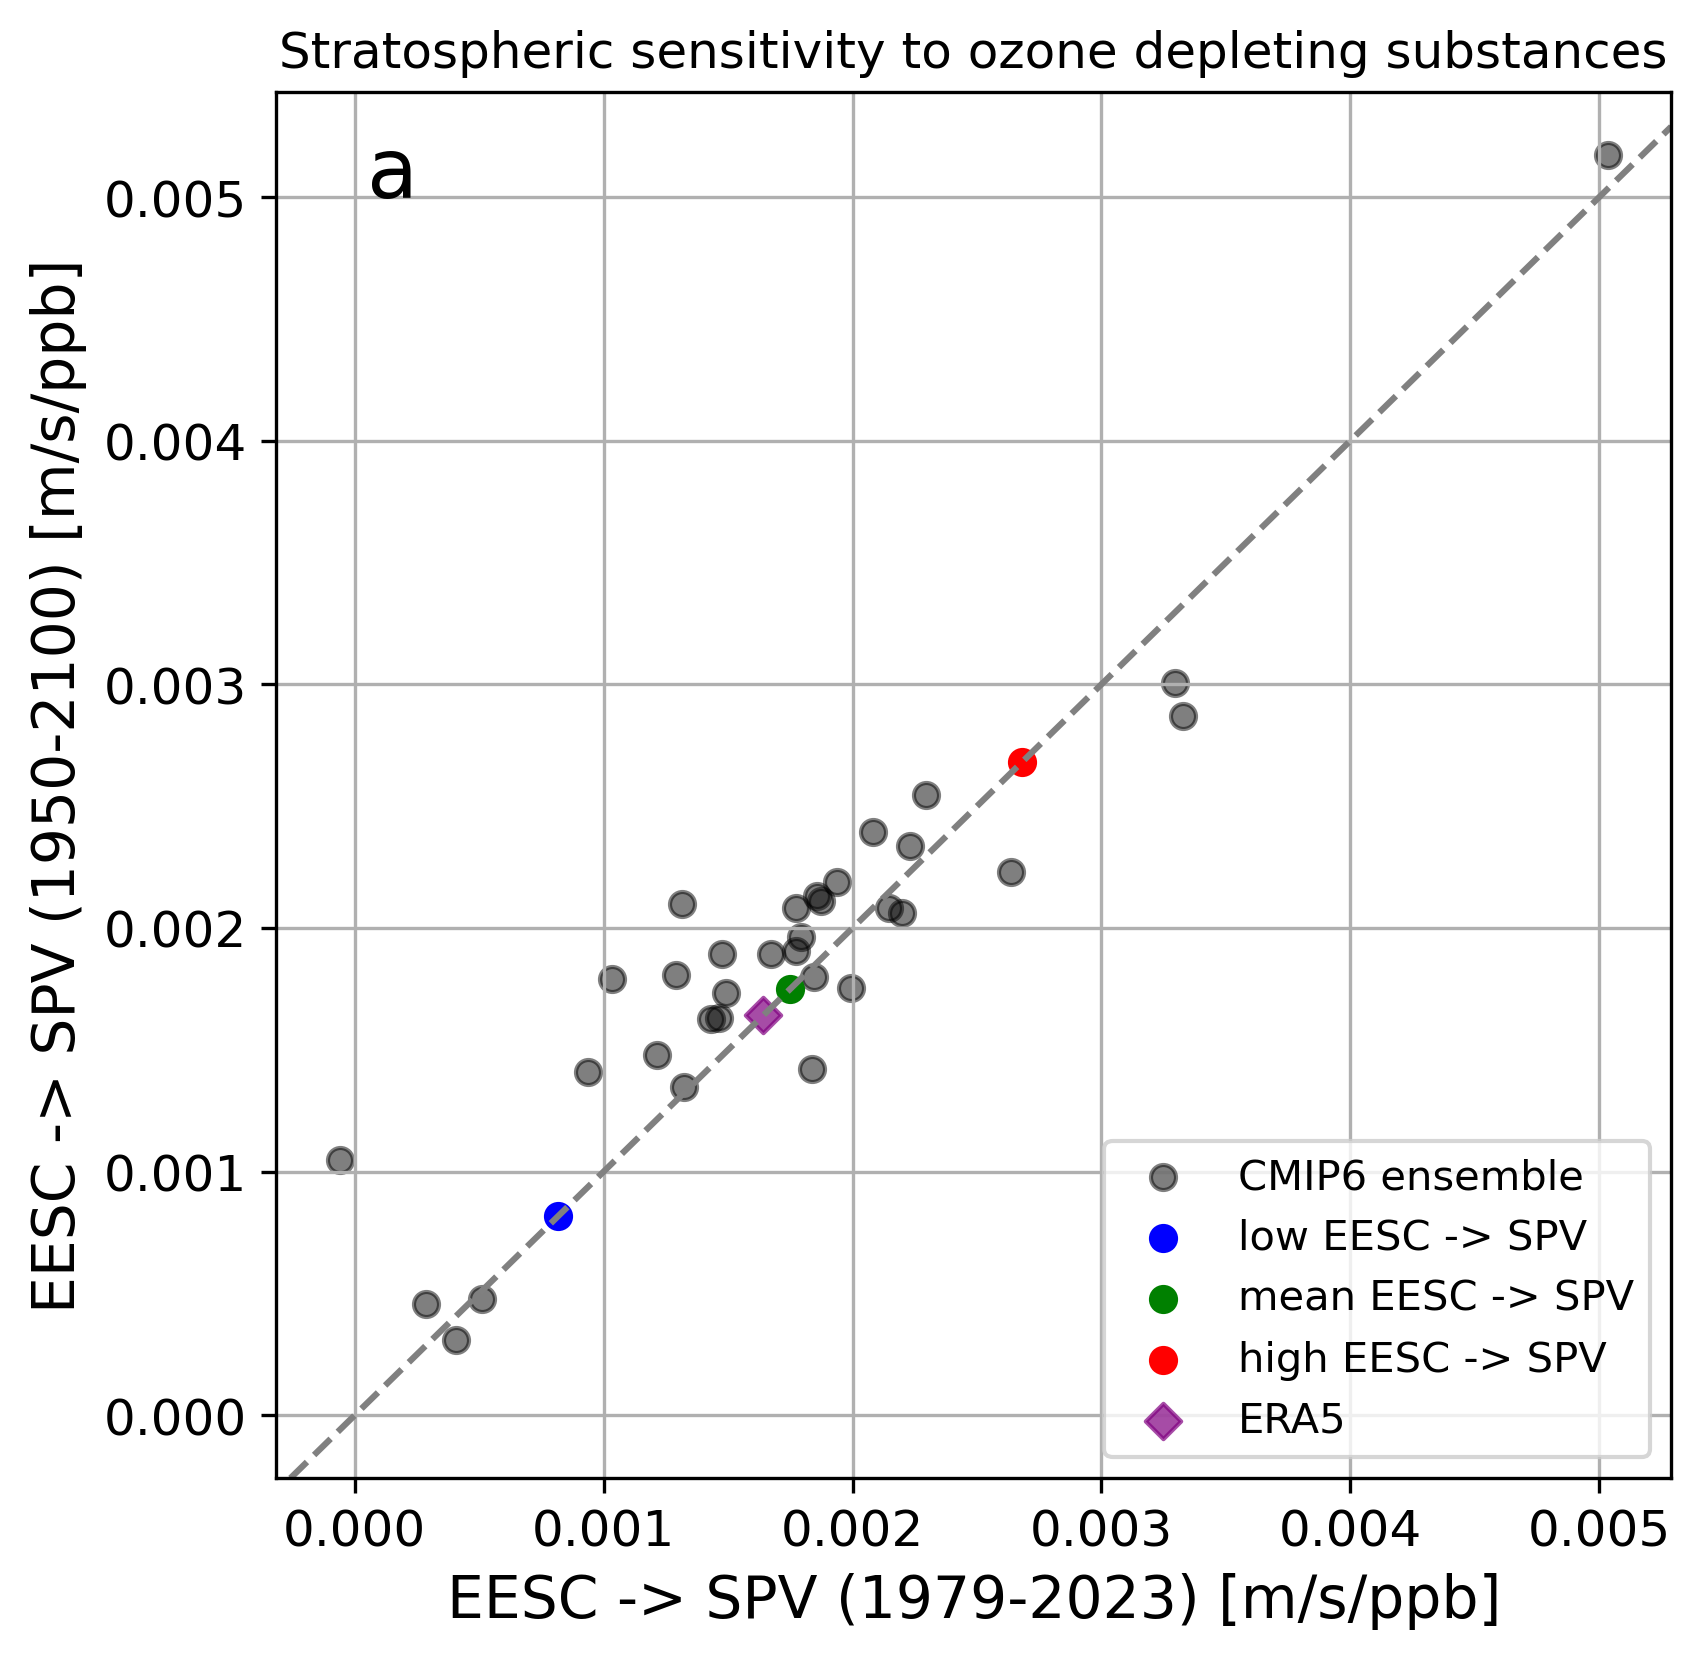

In [8]:
OBS_reg_EESC['EESC'][0]
EESC_1980_2000 = []
EESC_2080_2100 = []
for model in SPV_reg_80.keys():
    EESC_1980_2000.append(np.mean(SPV_reg_80[model][30:35])) 
    EESC_2080_2100.append(SPV_reg_full[model][0])

# Scatter plot
plt.figure(figsize=(6, 6),dpi=300)
plt.scatter(EESC_1980_2000,EESC_2080_2100, color='k',alpha=0.5,label='CMIP6 ensemble')
plt.scatter(np.mean(EESC_1980_2000) - np.std(EESC_1980_2000),np.mean(EESC_1980_2000) - np.std(EESC_1980_2000), color='b',label='low EESC -> SPV')
plt.scatter(np.mean(EESC_1980_2000) ,np.mean(EESC_1980_2000) , color='g',label='mean EESC -> SPV')
plt.scatter(np.mean(EESC_1980_2000) + np.std(EESC_1980_2000),np.mean(EESC_1980_2000) + np.std(EESC_1980_2000), color='r',label='high EESC -> SPV')
plt.scatter(OBS_reg_EESC['EESC'][0], OBS_reg_EESC['EESC'][0], marker='D',color='purple',alpha=0.7,label='ERA5')
plt.xlabel("EESC -> SPV (1979-2023) [m/s/ppb]",fontsize=14)
plt.ylabel("EESC -> SPV (1950-2100) [m/s/ppb]",fontsize=14)
plt.title("Stratospheric sensitivity to ozone depleting substances")
plt.axline((0, 0), slope=1, linestyle="--", color="gray")  # y=x reference line
plt.tick_params(axis='both', which='major', labelsize=12)  # Adjust label size
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.legend(loc='lower right')
plt.grid()
plt.text(0.00005, 0.005, 
         f"a", 
         fontsize=20)

plt.savefig('/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/plots/multiple_regression_indices/multiple_regresion/SPV_response_toEESC_stationarity.pdf', bbox_inches='tight')


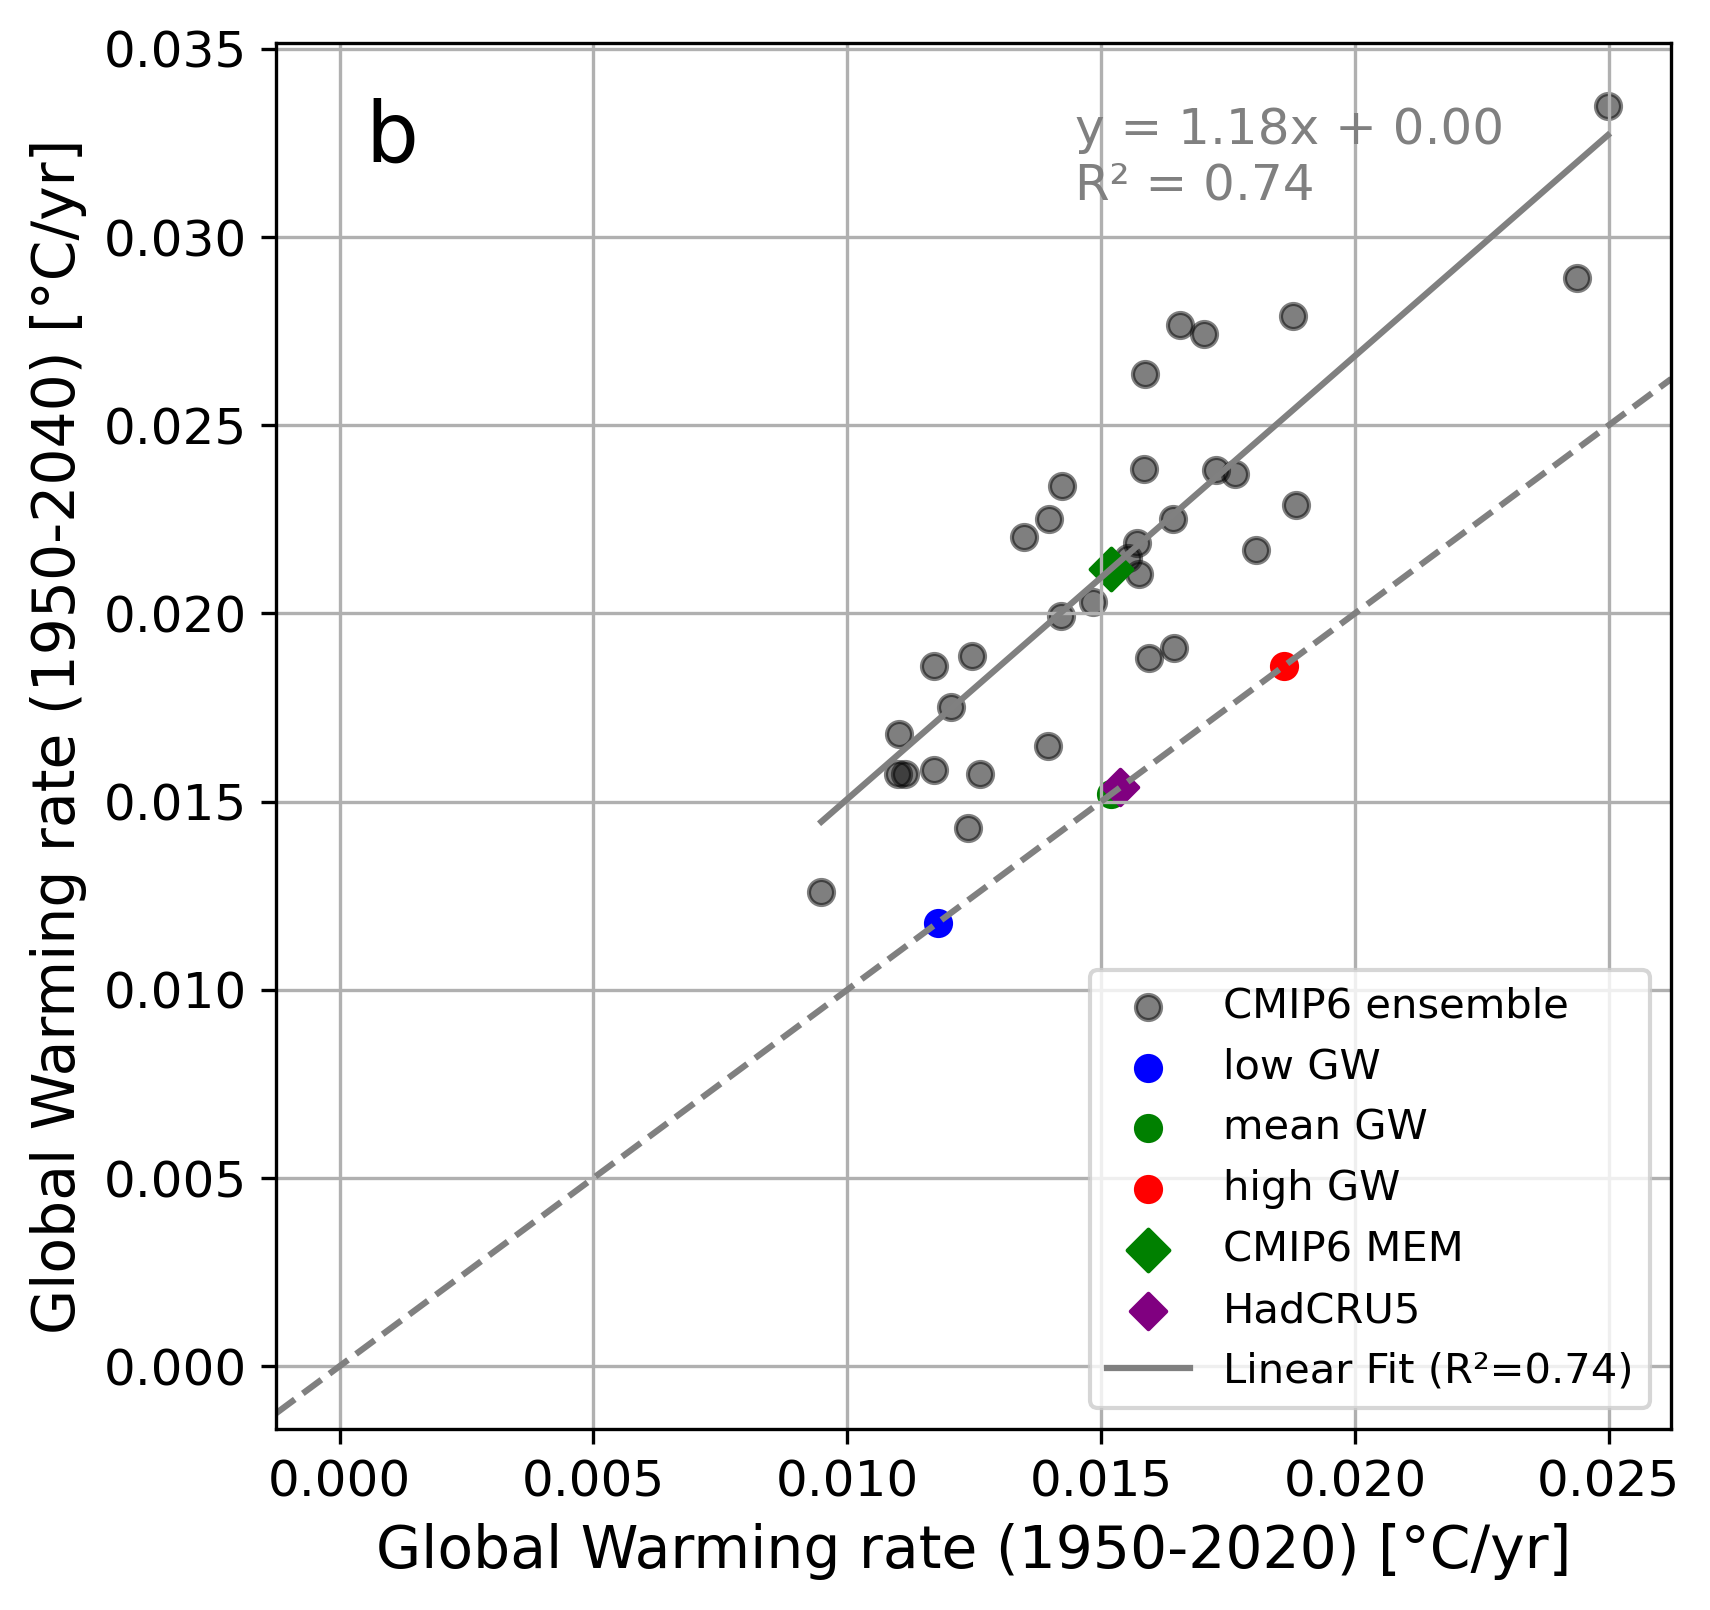

In [9]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assume 'final_gw' has dimensions (model, time)
years = final_gw["time"].values  # Extract time values
models = final_gw["model"].values  # Extract model names
rates_1980_2020 = []
rates_1980_2040 = []

for model in models:
    temp_series = final_gw.sel(model=model).tas - final_gw.sel(model=model).tas.sel(time=slice('1950','1979')).mean(dim='time')  # Extract model time series
    
    # Select the relevant years    
    temp_1 = temp_series.sel(time=slice('1950','2020'))
    temp_2 = temp_series.sel(time=slice('1950','2040'))
    
    # Extract years from cftime objects
    years_1 = np.array([t.year for t in temp_1["time"].values])
    years_2 = np.array([t.year for t in temp_2["time"].values])

    temps_1 = temp_1.values
    temps_2 = temp_2.values
    
    # Ensure lengths match
    if len(years_1) < 3 or len(years_2) < 3:  
        continue  # Skip if not enough data points for fitting

    # Fit quadratic polynomial y = a*x^2 + b*x + c
    coeffs_1 = np.polyfit(years_1, temps_1, 2)
    coeffs_2 = np.polyfit(years_2, temps_2, 2)
    
    # Rate of change is given by dy/dx = 2ax + b
    mid_1 = np.mean([1950, 2020])
    mid_2 = np.mean([1950, 2040])
    
    rate_1 = 2 * coeffs_1[0] * mid_1 + coeffs_1[1]
    rate_2 = 2 * coeffs_2[0] * mid_2 + coeffs_2[1]
    
    rates_1980_2020.append(rate_1)
    rates_1980_2040.append(rate_2)

# Read observational data
era_df = pd.read_csv('/climca/people/jmindlin/work_folders/EDJ_causal_network/Work/era5_ersst_drivers.csv',index_col='Unnamed: 0')
obs_gw = era_df['GW_DJF'][:-3].values
coeffs_obs = np.polyfit(years_1, obs_gw, 2)
rate_obs = 2 * coeffs_obs[0] * mid_1 + coeffs_obs[1]

# Multi-model mean
mem_gw = anom(final_gw.tas.sel(time=slice('1950','2023')).mean(dim='model').values)[:-3]
coeffs_mem_gw = np.polyfit(years_1, mem_gw, 2)
rate_mem_gw = 2 * coeffs_mem_gw[0] * mid_1 + coeffs_mem_gw[1]
mem_gw_fut = anom(final_gw.tas.sel(time=slice('1950','2040')).mean(dim='model').values)[:]
coeffs_mem_gw_fut = np.polyfit(years_2, mem_gw_fut, 2)
rate_mem_gw_fut = 2 * coeffs_mem_gw_fut[0] * mid_2 + coeffs_mem_gw_fut[1]

# Compute correlation and linear regression
slope, intercept, r_value, p_value, std_err = linregress(rates_1980_2020, rates_1980_2040)
r_squared = r_value ** 2  # Compute R²

# Generate regression line
x_fit = np.linspace(min(rates_1980_2020), max(rates_1980_2020), 100)
y_fit = slope * x_fit + intercept

# Scatter plot
plt.figure(figsize=(6, 6),dpi=300)
plt.scatter(rates_1980_2020, rates_1980_2040, color='k', alpha=0.5, label='CMIP6 ensemble')
plt.scatter(np.mean(rates_1980_2020) - np.std(rates_1980_2020), np.mean(rates_1980_2020) - np.std(rates_1980_2020), color='b' ,label='low GW')
plt.scatter(np.mean(rates_1980_2020) , np.mean(rates_1980_2020) , color='g' ,label='mean GW')
plt.scatter(np.mean(rates_1980_2020) + np.std(rates_1980_2020), np.mean(rates_1980_2020) + np.std(rates_1980_2020), color='r' ,label='high GW')
plt.scatter(rate_mem_gw, rate_mem_gw_fut, color='g', marker='D',s=50,label='CMIP6 MEM')
plt.scatter(rate_obs, rate_obs, color='purple', marker='D',label='HadCRU5')

# Plot regression line
plt.plot(x_fit, y_fit, color='grey', linestyle='-', label=f'Linear Fit (R²={r_squared:.2f})')

# Labels & Formatting
plt.xlabel("Global Warming rate (1950-2020) [°C/yr]",fontsize=14)
plt.ylabel("Global Warming rate (1950-2040) [°C/yr]",fontsize=14)
plt.axline((0, 0), slope=1, linestyle="--", color="gray")  # y=x reference line
plt.tick_params(axis='both', which='major', labelsize=12)  # Adjust label size
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.grid()
plt.legend(loc='lower right')

# Add linear fit equation and R² to the plot
plt.text(0.0005, 0.032, 
         f"b", 
         fontsize=20)
plt.text(min(rates_1980_2020)+0.005, max(rates_1980_2040), 
         f"y = {slope:.2f}x + {intercept:.2f}\nR² = {r_squared:.2f}", 
         fontsize=12, color="grey", verticalalignment='top')

plt.savefig('/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/plots/multiple_regression_indices/multiple_regresion/Global_warming_stationarity.pdf', bbox_inches='tight')
